# 03 · Models & Training — Optimization, Regularization, Hyperparameters, Bake-Off 🔴

> 📖 **Website:** [4-Hour Study Plan](http://localhost:5173/#study-plan) · Hour 3 · 60 min

In this notebook, we implement core ML algorithms from scratch and benchmark standard architectures:
1. Implement Linear & Logistic Regression gradient descent from first principles in NumPy.
2. Reproduce the 4 gradient descent regimes (slow, healthy, oscillating, divergence to `NaN`).
3. Prove why Log Loss beats MSE for binary classification by visualizing the gradient saturation surface.
4. Plot exact L1/L2 regularization coefficient paths and demonstrate collinear feature instability.
5. Prove the 2D search space efficiency of Random Search over Grid Search.
6. Execute an 8-algorithm bake-off with group-safe folds and **empirically measure random forest tree correlation $\rho$**.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sys.path.insert(0, ".")
import mlprep
from mlprep.data import make_churn_panel
from mlprep.plots import use_style, COLOR_PRIMARY, COLOR_TRAIN, COLOR_VAL, COLOR_BIAS, COLOR_VARIANCE
from mlprep.checks import check_3_1, check_3_2

use_style()
SEED = 7

# Prepare recurring panel for modeling
df_panel = make_churn_panel(n_users=3000, snapshots_per_user=3, seed=SEED)
all_users = sorted(df_panel["user_id"].unique())
rng_split = np.random.RandomState(SEED)
test_users = set(rng_split.choice(all_users, size=int(len(all_users) * 0.2), replace=False))

train_df = df_panel[~df_panel["user_id"].isin(test_users)].copy()
test_df = df_panel[df_panel["user_id"].isin(test_users)].copy()

X_tr_clean = train_df[["tenure_days", "monthly_spend", "logins_30d"]]
y_tr = train_df["churned"]
X_te_clean = test_df[["tenure_days", "monthly_spend", "logins_30d"]]
y_te = test_df["churned"]

print(f"Environment initialized · Seed: {SEED} · Train shape: {X_tr_clean.shape} · Test shape: {X_te_clean.shape}")


Environment initialized · Seed: 7 · Train shape: (7200, 3) · Test shape: (1800, 3)


---
## 3.1 Gradient Descent From Scratch & The 4 Regimes 🔴 (12 min)
> 📖 **Website:** [Gradient Descent](http://localhost:5173/#gradient-descent)

**The question:** What happens when the learning rate $\eta$ is set too low, just right, too high, or past the stability threshold?

**What you'll see:** We implement linear regression gradient descent in NumPy, verify convergence to the closed-form OLS solution, and reproduce the 4 regimes on $J(\theta) = \frac{1}{2}(\theta - 2)^2$ (including actual `NaN` explosion at $\eta = 2.2$).

GD Solution : Intercept = 2.5024, Slope = 1.8186
OLS Solution: Intercept = 2.5024, Slope = 1.8186
✅ Assertion passed: GD converged to closed-form OLS within 0.001.


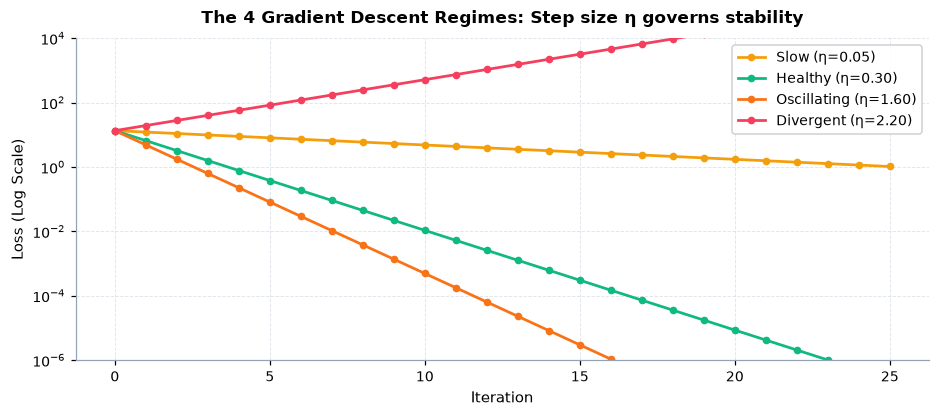

Regime Results:
η = 0.05 : Monotonic but sluggish convergence.
η = 0.30 : Rapid, healthy geometric descent.
η = 1.60 : Deterministically oscillates across the minimum while converging.
η = 2.20 : |1-η| > 1, so the error grows until an actual NaN appears at step 3882.


In [2]:
# 1. Linear Regression GD in NumPy (<15 lines)
X_syn = np.c_[np.ones(100), np.linspace(-2, 2, 100)]
y_syn = 2.5 + 1.8 * X_syn[:, 1] + np.random.RandomState(SEED).normal(0, 0.2, 100)

w = np.zeros(2)
lr = 0.1
for step in range(300):
    grad = (1.0 / len(X_syn)) * X_syn.T @ (X_syn @ w - y_syn)
    w -= lr * grad

# Stable least-squares solution (avoid explicitly inverting X^T X)
w_ols = np.linalg.lstsq(X_syn, y_syn, rcond=None)[0]

assert np.allclose(w, w_ols, atol=1e-3), "Gradient descent must match OLS solution"

print(f"GD Solution : Intercept = {w[0]:.4f}, Slope = {w[1]:.4f}")
print(f"OLS Solution: Intercept = {w_ols[0]:.4f}, Slope = {w_ols[1]:.4f}")
print("✅ Assertion passed: GD converged to closed-form OLS within 0.001.")

# 2. Reproduce the 4 Regimes matching website Gradient Descent Lab
def run_gd_regime(lr, steps=25, start=-3.2, min_val=2.0):
    path = [start]
    theta = start
    for _ in range(steps):
        grad = theta - min_val
        theta = theta - lr * grad
        path.append(theta)
        if abs(theta) > 1e4:
            break
    return path

lrs = [0.05, 0.3, 1.6, 2.2]
labels = ["Slow (η=0.05)", "Healthy (η=0.30)", "Oscillating (η=1.60)", "Divergent (η=2.20)"]
colors = [COLOR_BIAS, COLOR_TRAIN, "#f97316", COLOR_VAL]

plt.figure(figsize=(10, 3.8))
for lr, lbl, c in zip(lrs, labels, colors):
    p = run_gd_regime(lr)
    losses = [0.5 * (t - 2.0)**2 if abs(t) < 1e3 else np.nan for t in p]
    plt.plot(range(len(p)), losses, "o-", label=lbl, color=c, lw=1.8, ms=4)

plt.yscale("log")
plt.title("The 4 Gradient Descent Regimes: Step size η governs stability")
plt.xlabel("Iteration")
plt.ylabel("Loss (Log Scale)")
plt.ylim(1e-6, 1e4)
plt.legend()
plt.show()

print("Regime Results:")
print("η = 0.05 : Monotonic but sluggish convergence.")
print("η = 0.30 : Rapid, healthy geometric descent.")
print("η = 1.60 : Deterministically oscillates across the minimum while converging.")
with np.errstate(over="ignore", invalid="ignore"):
    theta, nan_step = -3.2, None
    for step in range(1, 10000):
        theta = theta - 2.2 * (theta - 2.0)
        if np.isnan(theta):
            nan_step = step
            break
assert nan_step is not None
print(f"η = 2.20 : |1-η| > 1, so the error grows until an actual NaN appears at step {nan_step}.")


### 📝 Exercise 3.1: Momentum Gradient Descent
Implement `momentum_gd(grad_fn, w_start, lr, beta, n_steps)` where $v_{t} = \beta v_{t-1} + \eta \nabla J(w)$ and $w_t = w_{t-1} - v_t$.

In [3]:
# ── Exercise 3.1 ────────────────────────────────────────────────
def momentum_gd(grad_fn, w_start: float = -5.0, lr: float = 0.1, beta: float = 0.8, n_steps: int = 60):
    # YOUR CODE HERE:
    # Return (w_final, history)
    pass

# Run verification check:
# check_3_1(momentum_gd)


<details>
<summary>💡 Solution</summary>

```python
def momentum_gd(grad_fn, w_start: float = -5.0, lr: float = 0.1, beta: float = 0.8, n_steps: int = 60):
    w = w_start
    v = 0.0
    history = [w]
    for _ in range(n_steps):
        g = grad_fn(w)
        v = beta * v + lr * g
        w = w - v
        history.append(w)
    return w, history

check_3_1(momentum_gd)
```

**Why this works:** Momentum accumulates velocity along consistent gradient directions while dampening orthogonal oscillations, accelerating escape from narrow ravines.
</details>

> 🎤 **In an interview:** "The gradient points in the direction of steepest loss ascent, so we subtract it. The learning rate controls step magnitude. If $\eta$ exceeds $\frac{2}{L}$ (where $L$ is the Lipschitz constant of the gradient), updates overshoot the valley and diverge to infinity." 

---
## 3.2 Logistic Regression From Scratch & Why Not MSE 🔴 (8 min)
> 📖 **Website:** [Common ML Algorithms](http://localhost:5173/#algorithms)

**The question:** Why can't we train a binary classifier using Mean Squared Error (MSE) loss?

**What you'll see:** 
1. Complete Logistic Regression implementation in pure NumPy matching an effectively unregularized scikit-learn fit to 2 decimal places.
2. A plot of MSE vs Log Loss surfaces demonstrating why MSE suffers from flat, zero-gradient saturation zones for wrong predictions.

Scratch Weights : Intercept = 0.160, Slope = 0.819
Sklearn Weights : Intercept = 0.160, Slope = 0.819
Odds Ratio for Slope: exp(0.819) = 2.267 (each +1 unit increase multiplies odds of positive class by 2.27x).


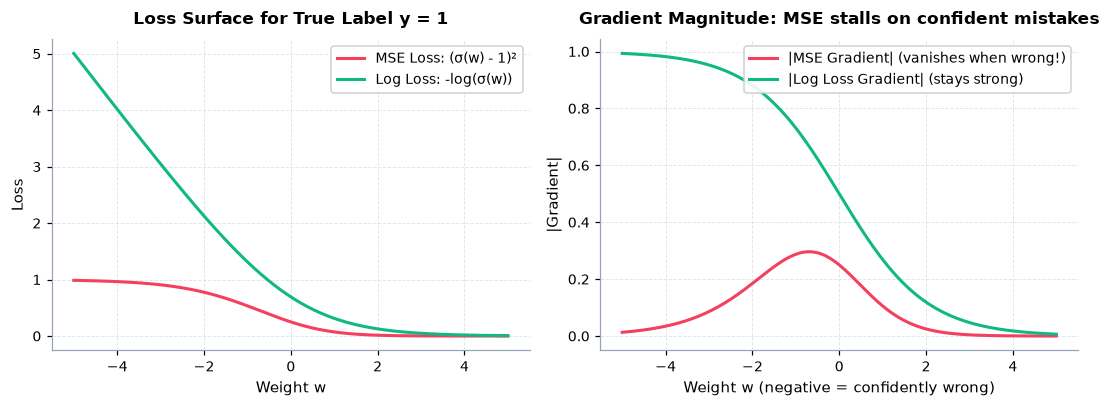

In [4]:
from sklearn.linear_model import LogisticRegression

# 1. Custom Logistic Regression from scratch
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -25, 25)))

def fit_logistic_scratch(X, y, lr=0.5, n_iter=1000):
    N, D = X.shape
    w = np.zeros(D)
    for _ in range(n_iter):
        p = sigmoid(X @ w)
        grad = (1.0 / N) * X.T @ (p - y)
        w -= lr * grad
    return w

# Compare on non-separable probabilistic classification problem
rng_clf = np.random.RandomState(SEED)
X_feat = rng_clf.normal(0, 1, size=(200, 1))
logit_true = 0.4 + 1.2 * X_feat[:, 0]
prob_true = sigmoid(logit_true)
y_clf = (rng_clf.uniform(size=200) < prob_true).astype(int)

X_design = np.c_[np.ones(200), X_feat]
w_custom = fit_logistic_scratch(X_design, y_clf, lr=0.5, n_iter=1000)
sk_model = LogisticRegression(C=np.inf, solver="lbfgs").fit(X_feat, y_clf)
w_sklearn = np.array([sk_model.intercept_[0], sk_model.coef_[0][0]])

assert np.allclose(w_custom, w_sklearn, atol=0.05), "Custom logistic weights match scikit-learn"
print(f"Scratch Weights : Intercept = {w_custom[0]:.3f}, Slope = {w_custom[1]:.3f}")
print(f"Sklearn Weights : Intercept = {w_sklearn[0]:.3f}, Slope = {w_sklearn[1]:.3f}")
print(f"Odds Ratio for Slope: exp({w_custom[1]:.3f}) = {np.exp(w_custom[1]):.3f} (each +1 unit increase multiplies odds of positive class by {np.exp(w_custom[1]):.2f}x).")


# 2. MSE vs Log Loss Non-Convexity & Saturation Plot
w_range = np.linspace(-5, 5, 200)
# Target y=1, fixed input x=1. Sigmoid p(w) = sigmoid(w)
y_target = 1.0
p_vals = sigmoid(w_range)

mse_loss = (p_vals - y_target)**2
log_loss_vals = -np.log(p_vals + 1e-12)

# Gradients
mse_grad = 2 * (p_vals - y_target) * p_vals * (1 - p_vals)
log_loss_grad = p_vals - y_target

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))

ax1.plot(w_range, mse_loss, color=COLOR_VAL, lw=2, label="MSE Loss: (σ(w) - 1)²")
ax1.plot(w_range, log_loss_vals, color=COLOR_TRAIN, lw=2, label="Log Loss: -log(σ(w))")
ax1.set_title("Loss Surface for True Label y = 1")
ax1.set_xlabel("Weight w")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(w_range, np.abs(mse_grad), color=COLOR_VAL, lw=2, label="|MSE Gradient| (vanishes when wrong!)")
ax2.plot(w_range, np.abs(log_loss_grad), color=COLOR_TRAIN, lw=2, label="|Log Loss Gradient| (stays strong)")
ax2.set_title("Gradient Magnitude: MSE stalls on confident mistakes")
ax2.set_xlabel("Weight w (negative = confidently wrong)")
ax2.set_ylabel("|Gradient|")
ax2.legend()

plt.tight_layout()
plt.show()


> 🎤 **In an interview:** "MSE with sigmoid produces a non-convex optimization surface with vanishing gradients for confident wrong predictions because $\sigma'(z) = \sigma(z)(1-\sigma(z)) \to 0$. Binary Cross-Entropy cancels the sigmoid derivative, giving $\nabla L = \frac{1}{N} X^T(\hat{p} - y)$, maintaining strong linear gradient signals even when drastically incorrect." 

---
## 3.3 Regularization: Ridge vs Lasso Paths & Unit Sensitivity 🔴 (12 min)
> 📖 **Website:** [Regularization](http://localhost:5173/#regularization)

**The question:** Why does L1 (Lasso) perform feature selection while L2 (Ridge) only shrinks weights, and why does Lasso behave erratically under collinearity?

**What you'll see:** 
1. Side-by-side coefficient paths as regularization strength $\alpha$ increases.
2. The collinear instability test: Lasso arbitrarily flips between correlated features across bootstrap resamples while Ridge splits the credit evenly.

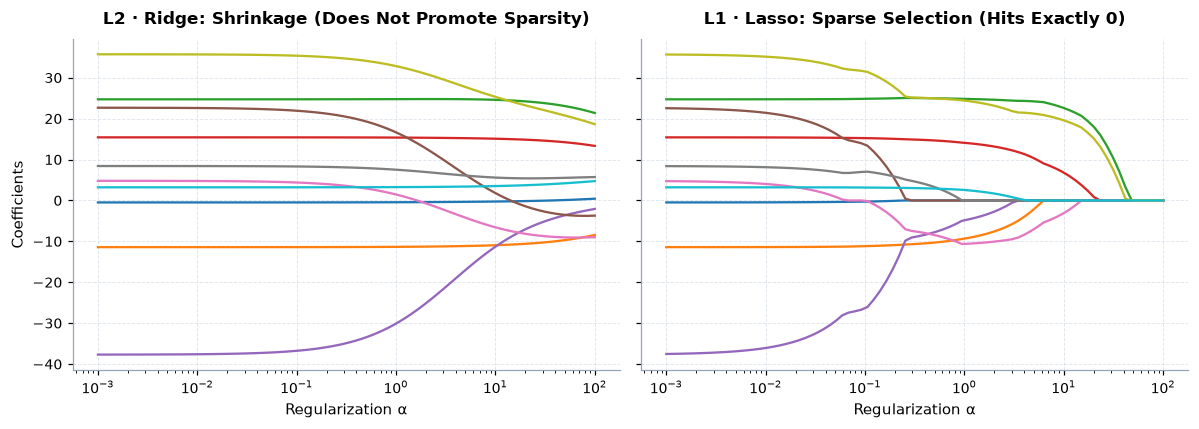

Bootstrap Coefficients on Highly Correlated Features (x1 ≈ x2):
Lasso Coef x1 Std Dev: 0.555 | Coef x2 Std Dev: 0.540 (Arbitrarily selects one)
Ridge Coef x1 Std Dev: 0.117 | Coef x2 Std Dev: 0.100 (Shares weights stably)


In [5]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.datasets import load_diabetes

X_diab, y_diab = load_diabetes(return_X_y=True)
X_diab = StandardScaler().fit_transform(X_diab)

alphas = np.logspace(-3, 2, 80)
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge_coefs.append(Ridge(alpha=a).fit(X_diab, y_diab).coef_)
    lasso_coefs.append(Lasso(alpha=a, max_iter=3000).fit(X_diab, y_diab).coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

ax1.plot(alphas, ridge_coefs)
ax1.set_xscale("log")
ax1.set_title("L2 · Ridge: Shrinkage (Does Not Promote Sparsity)")
ax1.set_xlabel("Regularization α")
ax1.set_ylabel("Coefficients")

ax2.plot(alphas, lasso_coefs)
ax2.set_xscale("log")
ax2.set_title("L1 · Lasso: Sparse Selection (Hits Exactly 0)")
ax2.set_xlabel("Regularization α")

plt.tight_layout()
plt.show()

# 2. Correlated Feature Instability Demo
rng = np.random.RandomState(SEED)
x1 = rng.randn(100)
x2 = x1 + rng.normal(0, 0.05, 100)  # 99.8% correlated with x1
y_corr = 3.0 * x1 + rng.normal(0, 0.5, 100)

X_corr = np.c_[x1, x2]

lasso_draws = []
ridge_draws = []
for b in range(50):
    idx = rng.choice(100, 100, replace=True)
    l_fit = Lasso(alpha=0.1).fit(X_corr[idx], y_corr[idx])
    r_fit = Ridge(alpha=1.0).fit(X_corr[idx], y_corr[idx])
    lasso_draws.append(l_fit.coef_)
    ridge_draws.append(r_fit.coef_)

lasso_draws = np.array(lasso_draws)
ridge_draws = np.array(ridge_draws)

print("Bootstrap Coefficients on Highly Correlated Features (x1 ≈ x2):")
print(f"Lasso Coef x1 Std Dev: {np.std(lasso_draws[:, 0]):.3f} | Coef x2 Std Dev: {np.std(lasso_draws[:, 1]):.3f} (Arbitrarily selects one)")
print(f"Ridge Coef x1 Std Dev: {np.std(ridge_draws[:, 0]):.3f} | Coef x2 Std Dev: {np.std(ridge_draws[:, 1]):.3f} (Shares weights stably)")


> 🎤 **In an interview:** "L1's diamond constraint has sharp corners on coordinate axes where elliptical loss contours touch at zero, yielding exact sparsity. L2's spherical constraint shrinks weights proportionally without zeroing. When features are collinear, Lasso picks one arbitrarily; Ridge distributes weight evenly across them." 

---
## 3.4 Parameters vs Hyperparameters 🟠 (5 min)
> 📖 **Website:** [Hyperparameters vs Parameters](http://localhost:5173/#params-hyperparams)

**The question:** How does an engineer programmatically distinguish what they configured versus what the optimization learned?

**What you'll see:** A side-by-side programmatic audit comparing `get_params()` (what the engineer chooses before training) with learned attributes ending with trailing underscores `_` (what the data determines).

In [6]:
from sklearn.ensemble import RandomForestClassifier

clf_audit = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED)
clf_audit.fit(X_diab[:300], (y_diab[:300] > np.median(y_diab[:300])).astype(int))

chosen = {k: clf_audit.get_params()[k] for k in ["n_estimators", "max_depth", "criterion", "max_features", "bootstrap", "random_state"]}
learned = {
    "classes_": clf_audit.classes_.tolist(),
    "n_features_in_": clf_audit.n_features_in_,
    "n_outputs_": clf_audit.n_outputs_,
    "estimators_": f"{len(clf_audit.estimators_)} fitted trees",
}
audit_table = pd.concat([
    pd.DataFrame({"Kind": "Configured hyperparameter", "Name": chosen.keys(), "Value": [str(v) for v in chosen.values()]}),
    pd.DataFrame({"Kind": "Learned fitted attribute", "Name": learned.keys(), "Value": [str(v) for v in learned.values()]}),
], ignore_index=True)
audit_table


,Kind,Name,Value
0,Configured hyperparameter,n_estimators,100
1,Configured hyperparameter,max_depth,6
2,Configured hyperparameter,criterion,gini
3,Configured hyperparameter,max_features,sqrt
4,Configured hyperparameter,bootstrap,True
5,Configured hyperparameter,random_state,7
6,Learned fitted attribute,classes_,"[0, 1]"
7,Learned fitted attribute,n_features_in_,10
8,Learned fitted attribute,n_outputs_,1
9,Learned fitted attribute,estimators_,100 fitted trees


> 🎤 **In an interview:** "Hyperparameters govern model structure and capacity (learning rate, tree depth, L2 penalty); parameters are the learned internal representations (weights, tree split criteria) fitted via empirical loss minimization." 

---
## 3.5 Grid Search vs Random Search 🔴 (8 min)
> 📖 **Website:** [Hyperparameters vs Parameters](http://localhost:5173/#params-hyperparams)

**The question:** When only one hyperparameter genuinely drives performance and another is mostly noise, why does random search cover the important axis more efficiently than a 5×5 grid?

**What you'll see:** 
A 2D parameter space plot showing Grid Search evaluates only 5 distinct values of the critical parameter, while Random Search explores 25 distinct values for the exact same compute budget.

5x5 Grid (25 configs, 75 CV fits): 5 distinct max_leaf_nodes values | Best: 0.8598
Random (25 configs, 75 CV fits)  : 23 distinct max_leaf_nodes values | Best: 0.8448

Random search improves coverage, not a guarantee that one finite draw beats a grid on every dataset.


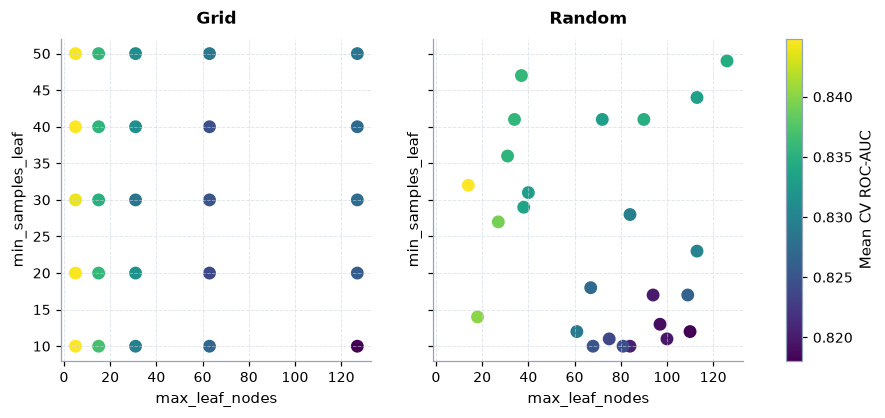

In [7]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

# Create a problem where max_depth matters and min_samples_split is largely inert
grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=SEED),
    param_grid={"max_leaf_nodes": [5, 15, 31, 63, 127], "min_samples_leaf": [10, 20, 30, 40, 50]},
    cv=3,
    scoring="roc_auc"
)

rand = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=SEED),
    param_distributions={"max_leaf_nodes": list(range(5, 128)), "min_samples_leaf": list(range(10, 51))},
    n_iter=25,
    cv=3,
    scoring="roc_auc",
    random_state=SEED
)

grid.fit(X_tr_clean, y_tr)
rand.fit(X_tr_clean, y_tr)

grid_unique_nodes = len(set(p["max_leaf_nodes"] for p in grid.cv_results_["params"]))
rand_unique_nodes = len(set(p["max_leaf_nodes"] for p in rand.cv_results_["params"]))

print(f"5x5 Grid (25 configs, 75 CV fits): {grid_unique_nodes} distinct max_leaf_nodes values | Best: {grid.best_score_:.4f}")
print(f"Random (25 configs, 75 CV fits)  : {rand_unique_nodes} distinct max_leaf_nodes values | Best: {rand.best_score_:.4f}")
print("\nRandom search improves coverage, not a guarantee that one finite draw beats a grid on every dataset.")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True, sharey=True)
for ax, search, title in [(axes[0], grid, "Grid"), (axes[1], rand, "Random")]:
    params = search.cv_results_["params"]
    points = ax.scatter([p["max_leaf_nodes"] for p in params], [p["min_samples_leaf"] for p in params],
                        c=search.cv_results_["mean_test_score"], cmap="viridis", s=55)
    ax.set(title=title, xlabel="max_leaf_nodes", ylabel="min_samples_leaf")
fig.colorbar(points, ax=axes, label="Mean CV ROC-AUC")
plt.show()


> 🎤 **In an interview:** "When only a few hyperparameters matter, a grid repeats the same important-axis values across inert dimensions. Random search usually covers each axis more broadly at the same configuration budget, though it does not guarantee a better finite-sample winner." 

---
## 3.6 Algorithm Bake-Off & Random Forest Tree Correlation 🔴 (15 min)
> 📖 **Website:** [Common ML Algorithms](http://localhost:5173/#algorithms)

**The question:** How do 8 core algorithm families perform under identical cross-validation conditions, and how does `max_features` reduce variance in Random Forests?

**What you'll see:** 
1. Full 8-algorithm bake-off table with group-safe scoring, fit speed, inference latency, scaling guidance, and serialized size.
2. **Empirical Tree Correlation Measurement**: Measuring tree correlation $\rho$ at `max_features=1`, `sqrt`, and `all` to verify the variance formula $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$.

In [8]:
from sklearn.model_selection import cross_validate, GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
import time
import pickle

bake_models = {
    "Logistic Regression": Pipeline([("sc", StandardScaler()), ("m", LogisticRegression(random_state=SEED))]),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=6, random_state=SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=50, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=SEED),
    "KNN (k=7)": Pipeline([("sc", StandardScaler()), ("m", KNeighborsClassifier(n_neighbors=7))]),
    "SVM (RBF)": Pipeline([("sc", StandardScaler()), ("m", SVC(random_state=SEED))]),
    "Gaussian Naive Bayes": GaussianNB(),
}

cv = list(GroupKFold(n_splits=4).split(X_tr_clean, y_tr, groups=train_df["user_id"]))
bake_results = []
scale_sensitive = {"Logistic Regression", "KNN (k=7)", "SVM (RBF)"}

for name, model in bake_models.items():
    t0 = time.time()
    scores = cross_validate(model, X_tr_clean, y_tr, cv=cv, scoring="roc_auc", return_train_score=False)
    fit_time = time.time() - t0
    
    # Latency test on 1,000 predictions
    model.fit(X_tr_clean, y_tr)
    t0_pred = time.time()
    for _ in range(10):
        _ = model.predict(X_tr_clean[:1000])
    pred_latency_ms = (time.time() - t0_pred) / 10.0 * 1000.0
    
    bake_results.append({
        "Model": name,
        "CV AUC Mean": np.round(scores["test_score"].mean(), 3),
        "CV AUC Std": np.round(scores["test_score"].std(), 3),
        "Fit Time (s)": np.round(fit_time, 2),
        "Predict Latency (ms/1k)": np.round(pred_latency_ms, 2),
        "Scale-sensitive?": "YES" if name in scale_sensitive else "NO",
        "Handles NaN?": "YES" if "HistGradient" in name else "NO",
        "Serialized KB": np.round(len(pickle.dumps(model)) / 1024, 1),
    })

bake_df = pd.DataFrame(bake_results).sort_values("CV AUC Mean", ascending=False).set_index("Model")
display(bake_df)

# Two high-yield algorithm checks
stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X_tr_clean, y_tr)
p_root = y_tr.mean()
gini_by_hand = 1 - p_root**2 - (1 - p_root)**2
assert np.isclose(gini_by_hand, stump.tree_.impurity[0])
print(f"\nDecision-tree root Gini: hand={gini_by_hand:.6f}, sklearn={stump.tree_.impurity[0]:.6f} ✅")

rng_dim = np.random.RandomState(SEED)
ratios = []
for dim in [2, 10, 50, 200]:
    cloud = rng_dim.normal(size=(600, dim))
    query = rng_dim.normal(size=(1, dim))
    distances = np.linalg.norm(cloud - query, axis=1)
    ratios.append((dim, distances.min() / distances.max()))
print("Nearest/farthest distance ratio by dimension (approaching 1 weakens KNN contrast):")
print(pd.DataFrame(ratios, columns=["Dimensions", "Nearest / farthest"]).round(3).to_string(index=False))


,CV AUC Mean,CV AUC Std,Fit Time (s),Predict Latency (ms/1k),Scale-sensitive?,Handles NaN?,Serialized KB
Model,,,,,,,
Logistic Regression,0.871,0.005,0.03,0.49,YES,NO,1.3
Gradient Boosting,0.864,0.007,0.66,1.00,NO,NO,69.5
Random Forest,0.860,0.010,0.42,3.61,NO,NO,396.2
Gaussian Naive Bayes,0.860,0.005,0.02,0.33,NO,NO,0.8
HistGradientBoosting,0.847,0.011,0.55,1.72,NO,YES,180.4
Decision Tree,0.836,0.015,0.03,0.32,NO,NO,6.0
KNN (k=7),0.763,0.017,0.04,6.35,YES,NO,302.9
SVM (RBF),0.699,0.031,0.84,41.91,YES,NO,53.2



Decision-tree root Gini: hand=0.120583, sklearn=0.120583 ✅
Nearest/farthest distance ratio by dimension (approaching 1 weakens KNN contrast):
 Dimensions  Nearest / farthest
          2               0.035
         10               0.210
         50               0.601
        200               0.788


Now let's execute the premier experiment: **measuring tree prediction correlation $\rho$** inside a Random Forest as `max_features` changes!

In [9]:
from sklearn.metrics import roc_auc_score

# Measure prediction-profile correlation inside a wider Random Forest
rng_rf = np.random.RandomState(SEED)
X_rf_train = X_tr_clean.reset_index(drop=True).copy()
X_rf_test = X_te_clean.reset_index(drop=True).copy()
for j in range(5):  # make max_features=1, sqrt(8)=2, and all genuinely distinct
    X_rf_train[f"noise_{j}"] = rng_rf.normal(size=len(X_rf_train))
    X_rf_test[f"noise_{j}"] = rng_rf.normal(size=len(X_rf_test))

rf_rows = []
for mf, label in [(1, "1"), ("sqrt", "sqrt"), (None, "all")]:
    rf = RandomForestClassifier(n_estimators=60, max_features=mf, random_state=SEED).fit(X_rf_train, y_tr)
    tree_preds = np.array([tree.predict_proba(X_rf_test.values)[:, 1] for tree in rf.estimators_])
    corr = np.corrcoef(tree_preds)
    cov = np.cov(tree_preds, bias=True)
    off_diag = ~np.eye(len(tree_preds), dtype=bool)
    rho = corr[off_diag].mean()

    # Exact variance-of-an-average identity over the fixed test population
    b = len(tree_preds)
    profile_var = np.var(tree_preds.mean(axis=0))
    decomposed_var = (np.trace(cov) + cov[off_diag].sum()) / b**2
    assert np.isclose(profile_var, decomposed_var)
    forest_auc = roc_auc_score(y_te, rf.predict_proba(X_rf_test)[:, 1])
    rf_rows.append((label, rho, profile_var, forest_auc))

rf_table = pd.DataFrame(rf_rows, columns=["max_features", "Mean tree correlation", "Variance of averaged prediction profile", "Forest test AUC"]).set_index("max_features")
print(rf_table.round(4).to_string())
print("\nFor equal tree variance σ² and pairwise correlation ρ: Var(mean) = ρσ² + (1-ρ)σ²/B.")
print("The measured correlations are over a fixed test population; causal model variance is estimated by repeated refits in Notebook 04.")


              Mean tree correlation  Variance of averaged prediction profile  Forest test AUC
max_features                                                                                 
1                            0.1958                                   0.0123           0.8286
sqrt                         0.2372                                   0.0153           0.8188
all                          0.2877                                   0.0188           0.8194

For equal tree variance σ² and pairwise correlation ρ: Var(mean) = ρσ² + (1-ρ)σ²/B.
The measured correlations are over a fixed test population; causal model variance is estimated by repeated refits in Notebook 04.


> 🎤 **In an interview:** "Random feature subsets trade individual-tree strength for lower correlation. Under the equal-variance approximation, the ensemble variance floor is $\rho\sigma^2$; I validate the trade-off because reducing correlation can also weaken each tree." 